# Aula 8: Laboratório 3 — CNNs, PyTorch e Hugging Face
_Notebook gerado em 2025-10-08 11:28_

**Docente:** Eliezer de Souza da Silva  
**Disciplina:** Aprendizado Profundo (MDCC/UFC)

**Objetivos do laboratório**
- Revisar tensores e autograd no PyTorch.
- Usar `nn.Module` para construir CNNs simples.
- Explorar o ecossistema Hugging Face (`transformers`, `datasets`).
- Implementar um mini-CBIR (Content-Based Image Retrieval) usando embeddings de CNN.


## 0) Ambiente e Instalações (Colab/Local)
Se estiver no Google Colab, execute o bloco abaixo para instalar dependências úteis.
Em ambiente local, instale manualmente conforme necessário.


In [ ]:
# descomente as linhas abaixo se necessario
# !pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip -q install transformers datasets timm scikit-learn matplotlib pillow


In [ ]:
# %%
import os, math, time, random, itertools
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Utilidades de visão
import torchvision
from torchvision import datasets, transforms, models, utils as tvutils

# Hugging Face
try:
    from transformers import AutoModelForImageClassification, AutoImageProcessor
    from datasets import load_dataset
    HF_AVAILABLE = True
except Exception as e:
    HF_AVAILABLE = False

print('PyTorch:', torch.__version__)
print('Torchvision:', torchvision.__version__)
print('CUDA disponível?', torch.cuda.is_available()) # Configure o Colab para usar GPU `Runtime > Change runtime type`
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


## 1) Tensores no PyTorch — Recapitulação
- `torch.Tensor` é a estrutura fundamental.
- Aceleração por GPU e autograd são diferenciais.


In [2]:
# %%
x = torch.tensor([[1., 2.], [3., 4.]], requires_grad=True)
y = x + 2
z = y * y * 3
out = z.mean()
print('out =', out.item())

# Backprop
out.backward()
print('grad de x =\n', x.grad)


out = 64.5
grad de x =
 tensor([[4.5000, 6.0000],
        [7.5000, 9.0000]])


In [3]:
# %%
# Criação
x = torch.randn(3, 4)
y = torch.ones_like(x)

# Reshape
z1 = x.view(12)
z2 = x.view(-1, 2)

# Operações
w = torch.matmul(x.T, x)
print('x shape:', x.shape, '| y shape:', y.shape)
print('z1 shape:', z1.shape, '| z2 shape:', z2.shape)
print('w shape:', w.shape)


x shape: torch.Size([3, 4]) | y shape: torch.Size([3, 4])
z1 shape: torch.Size([12]) | z2 shape: torch.Size([6, 2])
w shape: torch.Size([4, 4])


## 2) Exercício — Softmax Estável
Implemente `stable_softmax(logits)` que recebe shape `(B, C)` e retorna probabilidades estáveis numericamente.
Dica: subtraia o máximo por linha antes da exponencial.


In [ ]:
# %%
def stable_softmax(logits: torch.Tensor) -> torch.Tensor:
    # TODO: implemente aqui
    maxlogits = logits.max(dim=1,keepdim=True)[0]
    exps = torch.exp(logits - maxlogits)
    probs = exps / exps.sum(dim=1, keepdim=True)
    return probs

def simple_softmax(logits: torch.Tensor) -> torch.Tensor:
    exps = torch.exp(logits)
    probs = exps / exps.sum(dim=1, keepdim=True)
    return probs

# teste rápido
logits = torch.tensor([[1000.0, 1001.0, 999.0],
                       [1.0, 2.0, 3.0]])
probs = stable_softmax(logits)
print('Probs (cada linha deve somar ~1.0):', probs.sum(dim=1))
probs = simple_softmax(logits)
print('Probs (cada linha deve somar ~1.0):', probs.sum(dim=1))


Probs (cada linha deve somar ~1.0): tensor([1., 1.])
Probs (cada linha deve somar ~1.0): tensor([nan, 1.])


## 3) Exercício — One-Hot Encoding
Implemente `one_hot(labels, C)` que retorna uma matriz `(B, C)`.
Dica: use `torch.zeros` e `.scatter_`.


O método `torch.scatter_` é uma operação in-place (que modifica o tensor original) que "espalha" valores de um tensor fonte para um tensor destino, usando índices especificados por outro tensor. É muito útil para tarefas como one-hot encoding ou atualizações esparsas em tensores.

Vamos ver os parâmetros:

- `dim`: A dimensão ao longo da qual os valores serão espalhados.
- `index`: Um tensor com os índices onde os valores do tensor fonte serão colocados no tensor destino.
- `src`: O tensor fonte contendo os valores a serem espalhados.
- `reduce`: Um método opcional de redução ('sum', 'mean', 'prod') para lidar com índices repetidos.



In [ ]:
# %%
def one_hot(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    B = labels.shape[0]
    # TODO: implemente aqui
    return None

# teste
labels = torch.tensor([0, 2, 1, 2])
print(one_hot(labels, 4))


tensor([[1., 0., 0., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.]])


## 4) Autograd — Verificando Gradientes
Considere `y = sum(log(x_i^2))`. Derive manualmente `dy/dx_i = 2/x_i` e verifique.


In [ ]:
# %%
x = torch.tensor([1.0, 2.0], requires_grad=True)
y = torch.log(x.pow(2)).sum()
y.backward()
print('x.grad (esperado [2.0, 1.0]) =', x.grad)


## 5) Autograd para Sistemas Dinâmicos Simples (ODE)
Equação: `dy/dt = -k y`. Método de Euler: `y_{t+1} = y_t - k y_t dt`.
Geraremos dados sintéticos e aprenderemos `k` via descida de gradiente.


k aprendido ~ 0.6954059600830078 | k verdadeiro = 0.7


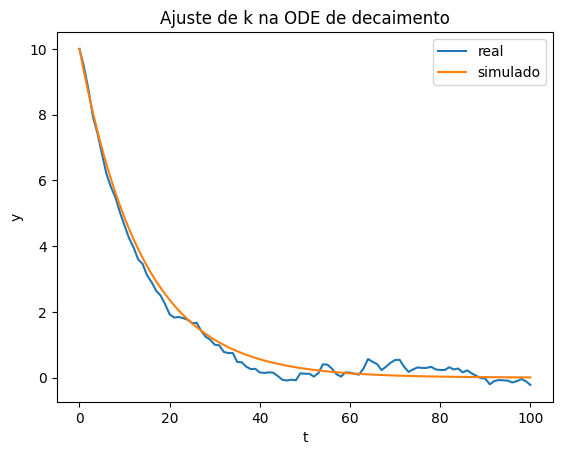

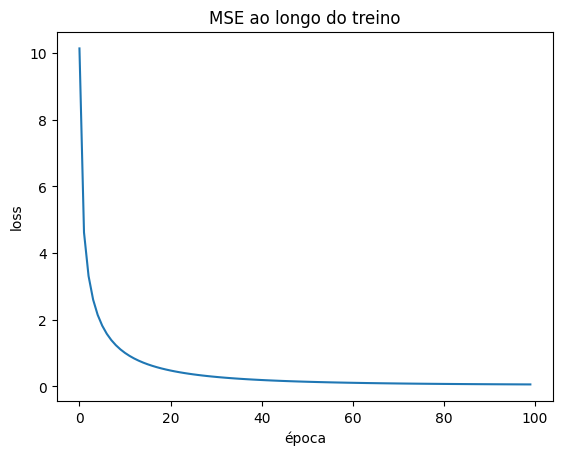

In [ ]:
# %%
torch.manual_seed(0)

# Dados sintéticos
true_k = 0.7
y0 = 10.0
dt = 0.1
T = 100

y_real = [y0]
for t in range(T):
    y_real.append(y_real[-1]- true_k * y_real[-1] * dt + torch.randn(1) * 0.1)
y_real = torch.tensor(y_real, dtype=torch.float32)

# Parâmetro a aprender
k = torch.tensor([0.2], dtype=torch.float32, requires_grad=True)

optimizer = torch.optim.SGD([k], lr=0.001)

def simulate(k):
    y = [torch.tensor([y0], dtype=torch.float32)]
    for t in range(T):
        y_next = y[-1]- k * y[-1] * dt
        y.append(y_next)
    return torch.stack(y).squeeze(-1)

losses = []
for epoch in range(100):
    optimizer.zero_grad()
    # TODO: implemente aqui
    losses.append(loss.item())

print('k aprendido ~', k.item(), '| k verdadeiro =', true_k)

# Plot
plt.figure()
plt.plot(y_real.numpy(), label='real')
plt.plot(simulate(k).detach().numpy(), label='simulado')
plt.legend(); plt.title('Ajuste de k na ODE de decaimento'); plt.xlabel('t'); plt.ylabel('y'); plt.show()

plt.figure()
plt.plot(losses)
plt.title('MSE ao longo do treino'); plt.xlabel('época'); plt.ylabel('loss'); plt.show()


## 6) `nn.Module` — CNN Simples + Fashion-MNIST
Treinaremos rapidamente uma CNN pequena (apenas algumas épocas) no Fashion-MNIST.


In [ ]:
# %%
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_ds = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16*14*14, 10)
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model = SimpleCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return correct/total

for epoch in range(2):  # poucas épocas para demo
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        # TODO: implemente aqui
    print(f'Época {epoch+1}: acc_teste = {accuracy(model, test_loader):.3f}')


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.7MB/s]


Época 1: acc_teste = 0.834
Época 2: acc_teste = 0.874


## 7) Visualizando os *kernels* da primeira camada
Filtros iniciais tendem a parecer detectores de bordas e gradientes.


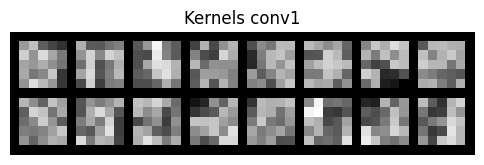

In [ ]:
# %%
with torch.no_grad():
    w = model.conv1.weight.cpu().clone()  # (16, 1, 5, 5)
    grid = tvutils.make_grid(w, nrow=8, normalize=True, padding=1)
plt.figure(figsize=(6,3))
plt.imshow(grid.permute(1,2,0).squeeze())
plt.axis('off'); plt.title('Kernels conv1'); plt.show()


## 8) Modelo de uma camada com *kernels* transferidos + Mapas de *features*
Copiamos os pesos da conv1 e vemos a resposta (mapas de ativação) para uma imagem.


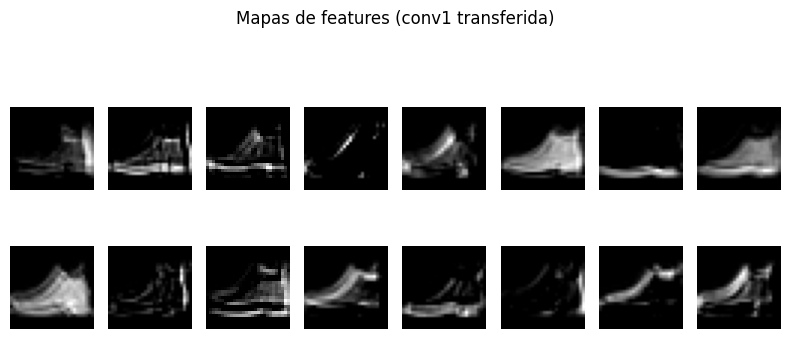

In [ ]:
# %%
class OneLayer(nn.Module):
    def __init__(self, weight):
        super().__init__()
        out_ch, in_ch, k, _ = weight.shape
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=k//2, bias=False)
        with torch.no_grad():
            self.conv.weight.copy_(weight)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.conv(x))

one = OneLayer(model.conv1.weight.data.clone()).to(device)

# Pegue uma imagem de teste
xb, yb = next(iter(test_loader))
img = xb[:1].to(device)  # (1,1,28,28)
with torch.no_grad():
    feats = one(img).cpu()  # (1, 16, 28, 28)

# Visualizar alguns mapas
plt.figure(figsize=(8,4))
for i in range(min(16, feats.shape[1])):
    plt.subplot(2,8,i+1)
    plt.imshow(feats[0,i].numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle('Mapas de features (conv1 transferida)'); plt.tight_layout(); plt.show()


## 9) Mini-CBIR: Busca por Similaridade de Imagens
Usaremos uma CNN pré-treinada (ResNet-18) para extrair *embeddings* e encontrar vizinhos mais próximos.
Para acelerar, usaremos um subconjunto de imagens.


Embeddings: torch.Size([2000, 512])


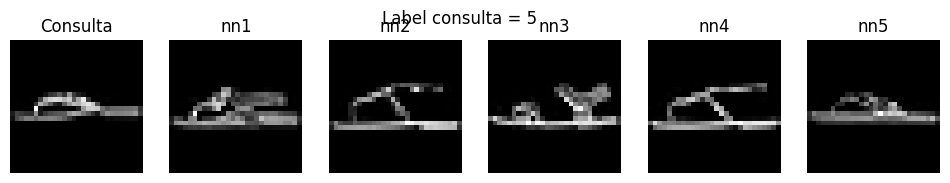

In [ ]:
# %%
from sklearn.neighbors import NearestNeighbors

# Usar resnet18 pré-treinada em ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
resnet.eval()

# Em vez da FC final, pegamos o penúltimo vetor (2048? Para resnet18 é 512)
embed_dim = resnet.fc.in_features
backbone = torch.nn.Sequential(*(list(resnet.children())[:-1]))  # até avgpool

def get_embeddings(dloader, max_items=2000):
    xs, ys, embs = [], [], []
    count = 0
    with torch.no_grad():
        for xb, yb in dloader:
            # expandir para 3 canais (Fashion é 1 canal)
            xb = xb.expand(-1,3,-1,-1).to(device)
            #  TODO: implemente aqui
    xs = torch.cat(xs)[:max_items]
    ys = torch.cat(ys)[:max_items]
    embs = torch.cat(embs)[:max_items]
    return xs, ys, embs

subset_loader = DataLoader(test_ds, batch_size=128, shuffle=False)
imgs, labels, embeddings = get_embeddings(subset_loader, max_items=2000)
print('Embeddings:', embeddings.shape)

# Ajustar kNN
nbrs = NearestNeighbors(n_neighbors=6, algorithm='auto', metric='euclidean')
nbrs.fit(embeddings.numpy())

def show_neighbors(query_idx=0):
    distances, indices = nbrs.kneighbors(embeddings[query_idx].unsqueeze(0).numpy(), n_neighbors=6)
    indices = indices[0]
    fig, axes = plt.subplots(1, 6, figsize=(12, 2))
    for i, ax in enumerate(axes):
        # pegue img dos vizinhos mais proximos
        # TODO: implemente aqui
        ax.imshow(img)
        ax.axis('off')
        if i==0: ax.set_title('Consulta')
        else: ax.set_title(f'nn{i}')
    plt.suptitle(f'Label consulta = {labels[query_idx].item()}'); plt.show()

show_neighbors(query_idx=8)


# %% [markdown]
## 10) Hugging Face — `datasets` e `transformers` (Opcional)
Carregaremos CIFAR-10 e um modelo de classificação de imagens do Hub, se disponível.


DatasetDict({
    test: Dataset({
        features: ['image'],
        num_rows: 1
    })
})


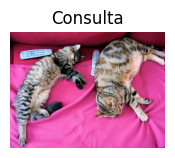

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Carregado do Hub: microsoft/resnet-18


In [ ]:
# %%
# Mostrar algumas imagens
import PIL.Image as Image
import numpy as np

def show_cats_batch(split='train', n=8):
    # Convert PIL Image objects to NumPy arrays before passing to Image.fromarray
    # Limit the number of images to the available number in the split
    num_images_to_show = min(n, len(ds[split]))
    imgs = [Image.fromarray(np.array(ds[split]['image'][i])) for i in range(num_images_to_show)]
    fig, axes = plt.subplots(1, num_images_to_show, figsize=(2*num_images_to_show,2))
    # Handle the case where there is only one image
    if num_images_to_show == 1:
        ax = axes
        img = imgs[0]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title('Consulta')
    else:
        for i, ax in enumerate(axes):
            img = imgs[i]
            ax.imshow(img)
            ax.axis('off')
            if i==0: ax.set_title('Consulta')
            else: ax.set_title(f'nn{i}')
    plt.show()


if HF_AVAILABLE:
      ds = load_dataset("huggingface/cats-image")
      print(ds)


      show_cats_batch('test', 1)

      model_id = 'microsoft/resnet-18'  # Modelo no Hub
      model = AutoModelForImageClassification.from_pretrained(model_id)
      proc  = AutoImageProcessor.from_pretrained(model_id)
      print('Carregado do Hub:', model_id)


---


## 11) Tarefas Finais
- Ajuste hiperparâmetros da `SimpleCNN` (filtros, tamanho do kernel, camadas) e avalie impacto na acurácia.
- Substitua o uso de ResNet-18 por outra arquitetura (`resnet50`, `mobilenet_v3_small`) no CBIR e compare resultados.
- Experimente diferentes métricas de distância no k-NN (cosine vs euclidean).

## Leitura Adicional
- Documentação PyTorch (tensors, autograd, nn): https://pytorch.org/docs/stable/index.html  
- Torchvision (modelos, datasets): https://pytorch.org/vision/stable/index.html  
- Hugging Face Transformers: https://huggingface.co/docs/transformers/index  
- Hugging Face Datasets: https://huggingface.co/docs/datasets/index  
